# Model Comparison

A notebook to compare the parameters of the different fitted brain models.

In [2]:
# Load the parameters

from hbnm.io import Data
input_dir = '/home/frank/HBNM/data/'
output_dir = '/home/frank/HBNM/outputs/'
data = Data(input_dir, output_dir)

In [3]:
# Demirtas Models
fin = data.load('demirtas_neuron_2019.hdf5', from_output=False)
theta_heterogeneous_Demirtas = fin['apprx_posterior_heterogeneous'][:5]
theta_homogeneous_Demirtas = fin['apprx_posterior_homogeneous'][:3]
fin.close()

# Homogeneous Models
fin = data.load('NTHC_Homo_Group/iteration_30.hdf5', from_output=True)
theta_homogeneous_NTHC = fin['theta'][:]
fin.close()

fin = data.load('Homogenous/iteration_20.hdf5', from_output=True)
theta_homogeneous_M1 = fin['theta'][:]
fin.close()

# Heterogeneous Models
fin = data.load('TEHC_Myelin_Group/iteration_50.hdf5', from_output=True)
theta_heterogeneous_TEHC = fin['theta'][:]
fin.close()
fin = data.load('NTHC_Myelin_Group/iteration_51.hdf5', from_output=True)
theta_heterogeneous_NTHC = fin['theta'][:]
fin.close()

fin = data.load('Heterogeneous_Dem_Range/iteration_53.hdf5', from_output=True)
theta_heterogeneous_HCP_M2 = fin['theta'][:]
fin.close()

fin = data.load('Heterogeneous_Old_Range/iteration_35.hdf5', from_output=True)
theta_heterogeneous_HCP_M1 = fin['theta'][:]
fin.close()

fin = data.load('NTS_Myelin_Group/iteration_50.hdf5', from_output=True)
theta_heterogeneous_NTS = fin['theta'][:]
fin.close()

fin =  data.load('TIS_Myelin_Group/iteration_50.hdf5', from_output=True)
theta_heterogeneous_TIS = fin['theta'][:]
fin.close()

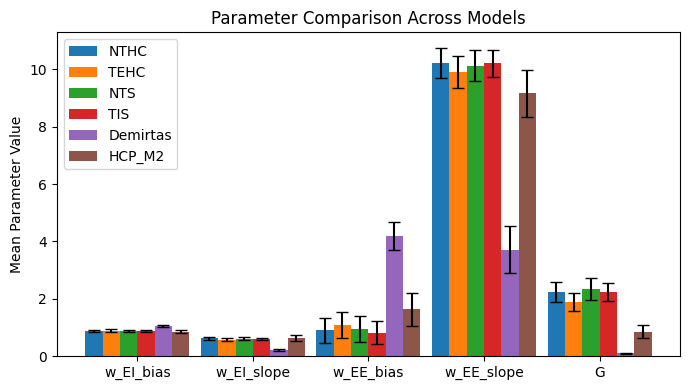

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Parameter order for plotting:
param_names = ['w_EI_bias', 'w_EI_slope', 'w_EE_bias', 'w_EE_slope', 'G']

# Models to Compare
model_dict = {
    'NTHC': theta_heterogeneous_NTHC,
    'TEHC': theta_heterogeneous_TEHC,
    'NTS': theta_heterogeneous_NTS,
    'TIS': theta_heterogeneous_TIS,
    'Demirtas': theta_heterogeneous_Demirtas,
    # 'HCP_M1': theta_heterogeneous_HCP_M1,
    'HCP_M2': theta_heterogeneous_HCP_M2
}

def get_param_means(model_array):
    """
    Compute the mean of each parameter across all particles for a model.
    Assumes shape (n_params, n_particles).
    """
    return np.mean(model_array, axis=1)

def get_param_stds(model_array):
    """
    Compute the std of each parameter across all particles for a model.
    Assumes shape (n_params, n_particles).
    """
    return np.std(model_array, axis=1)

def plot_model_comparison_bar(models, param_names):
    """
    Plot a bar plot comparing parameter means across models, with error bars (std).
    """
    n_params = len(param_names)
    n_models = len(models)
    bar_width = 0.15
    x = np.arange(n_params)

    plt.figure(figsize=(7, 4))
    for i, (model_name, model_array) in enumerate(models.items()):
        param_means = get_param_means(model_array)
        param_stds = get_param_stds(model_array)
        plt.bar(x + i*bar_width, param_means, width=bar_width, yerr=param_stds, capsize=4, label=model_name)
    
    plt.xticks(x + bar_width * (n_models-1)/2, param_names)
    plt.ylabel('Mean Parameter Value')
    plt.title('Parameter Comparison Across Models')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot the comparison
plot_model_comparison_bar(model_dict, param_names)

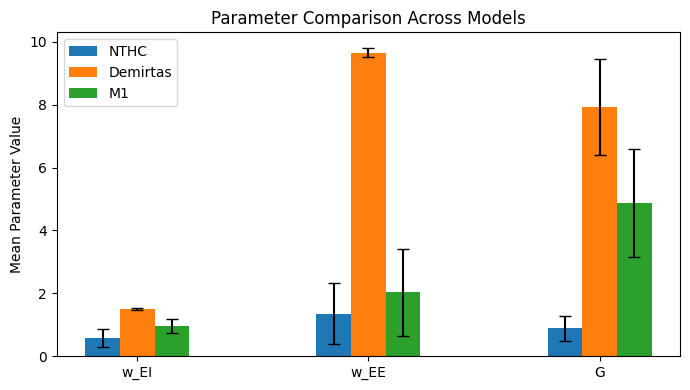

In [5]:
homogeneous_param_names = ['w_EI','w_EE','G']
homogeneous_model_dict = {
    'NTHC': theta_homogeneous_NTHC,
    'Demirtas': theta_homogeneous_Demirtas,
    'M1': theta_homogeneous_M1
}

# Plot the comparison
plot_model_comparison_bar(homogeneous_model_dict, homogeneous_param_names)

In [6]:
# Compute empirical FC distribution for each model